# Data Exploration
This exploratory data analysis (EDA) examines the Superstore dataset to understand key patterns in sales, profitability, customer behavior, and product performance. The goal is to build a clear foundation for later dashboard development by identifying trends, outliers, and structural drivers of business performance.
The analysis covers numerical and categorical distributions, time‑series trends, regional differences, product profitability, and customer segmentation.

## 0. Import libraries

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


## 1. Load Data

In [113]:
df = pd.read_csv("../data/raw/superstore.csv", encoding="latin1").set_index("Row ID")

numeric_cols = ["Sales", "Profit", "Quantity", "Discount"]
categorical_cols = ["Category", "Sub-Category", "Region", "Segment", "Ship Mode"]

## 2. First look at the data

In [114]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,,,,
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 1 to 9994
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Order Date     9994 non-null   object 
 2   Ship Date      9994 non-null   object 
 3   Ship Mode      9994 non-null   object 
 4   Customer ID    9994 non-null   object 
 5   Customer Name  9994 non-null   object 
 6   Segment        9994 non-null   object 
 7   Country        9994 non-null   object 
 8   City           9994 non-null   object 
 9   State          9994 non-null   object 
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   object 
 12  Product ID     9994 non-null   object 
 13  Category       9994 non-null   object 
 14  Sub-Category   9994 non-null   object 
 15  Product Name   9994 non-null   object 
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount     

## 3. Missing values

In [116]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## 4. Numerical columns

In this section, I explore the distribution and correlation of the main numerical variables: Sales, Profit, Quantity, and Discount. The goal is to understand skewness, outliers, and general patterns that may influence later analysis.

In [117]:
df[numeric_cols].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


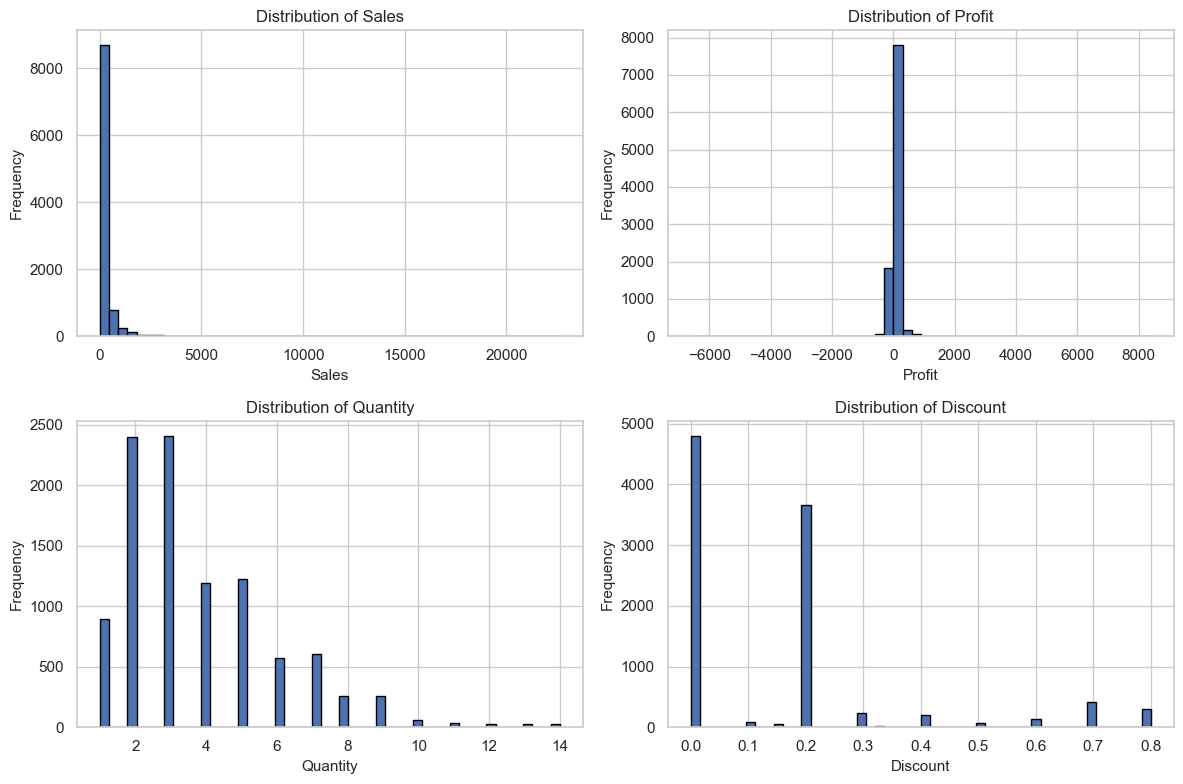

In [118]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=50, ax=axes[i], edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

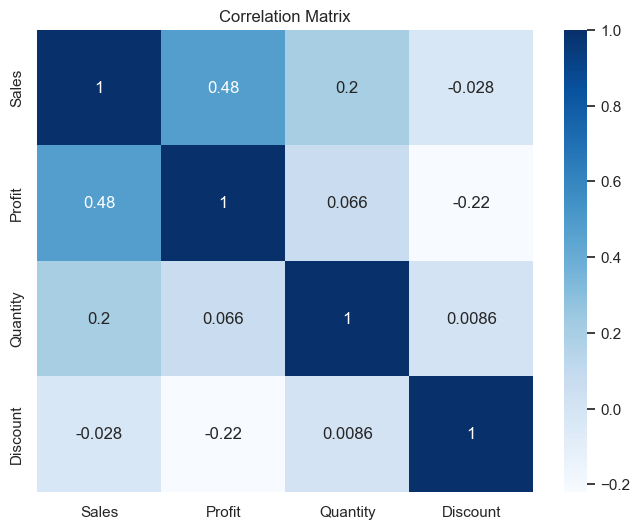

In [119]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()


Insights:
- Sales and Profit are heavily right‑skewed, suggesting a few very large transactions.
- Profit contains negative values, indicating unprofitable orders.
- Discount is discrete and often applied at specific levels (0%, 20%, 30%, etc.).
- Quantity is low‑integer and centered around small order sizes.
- Sales and Profit show a moderate positive correlation.
- Discount is negatively correlated with Profit, indicating that higher discounts reduce profitability.
- Quantity has weak correlations with other variables, suggesting order size is not a strong driver of revenue or profit.

These patterns suggest that a log transformation may be useful later for modeling, and that negative profit should be investigated by product and region.


## 5. Categorical columns

Next, I examine the distribution of key categorical variables to understand the composition of the dataset across product types, customer segments, and regions.


--- Category ---
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

--- Sub-Category ---
Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

--- Region ---
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

--- Segment ---
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

--- Ship Mode ---
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


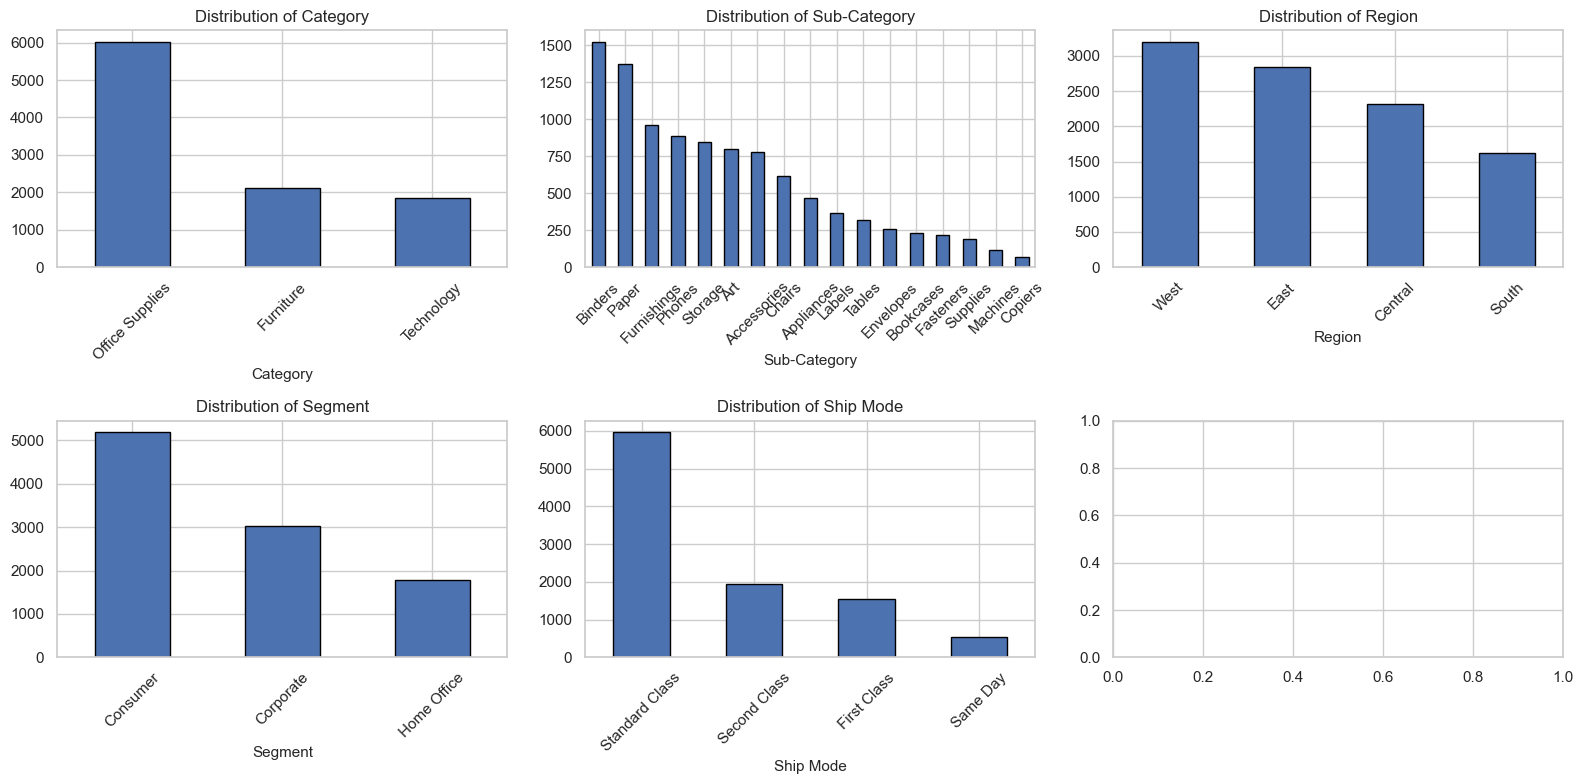

In [120]:
# Print value counts
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    df[col].value_counts().plot(
        kind="bar",
        ax=ax,
        color="#4C72B0",
        edgecolor="black"
    )
    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Insights:
- The West region has the highest number of orders.
- Standard Class is the dominant shipping mode.
- Most customers belong to the Consumer segment.
- Office Supplies is the most frequently purchased category.

These distributions help contextualize later profitability and sales patterns.

## 6. Date column

I convert the Order Date column to a datetime format and inspect the time span covered by the dataset.

In [121]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

print("First order: ", df["Order Date"].min()) 
print("Latest order: ", df["Order Date"].max())  # latest order

# Orders per year
df["Order Date"].dt.year.value_counts().sort_index()

First order:  2014-01-03 00:00:00
Latest order:  2017-12-30 00:00:00


Order Date
2014    1993
2015    2102
2016    2587
2017    3312
Name: count, dtype: int64

The dataset spans three full years, with a clear increase in order volume over time.

## 7. Outlier Detection
I use boxplots to identify outliers in the numerical variables. Outliers may indicate unusual transactions, high‑discount orders, or extreme losses.

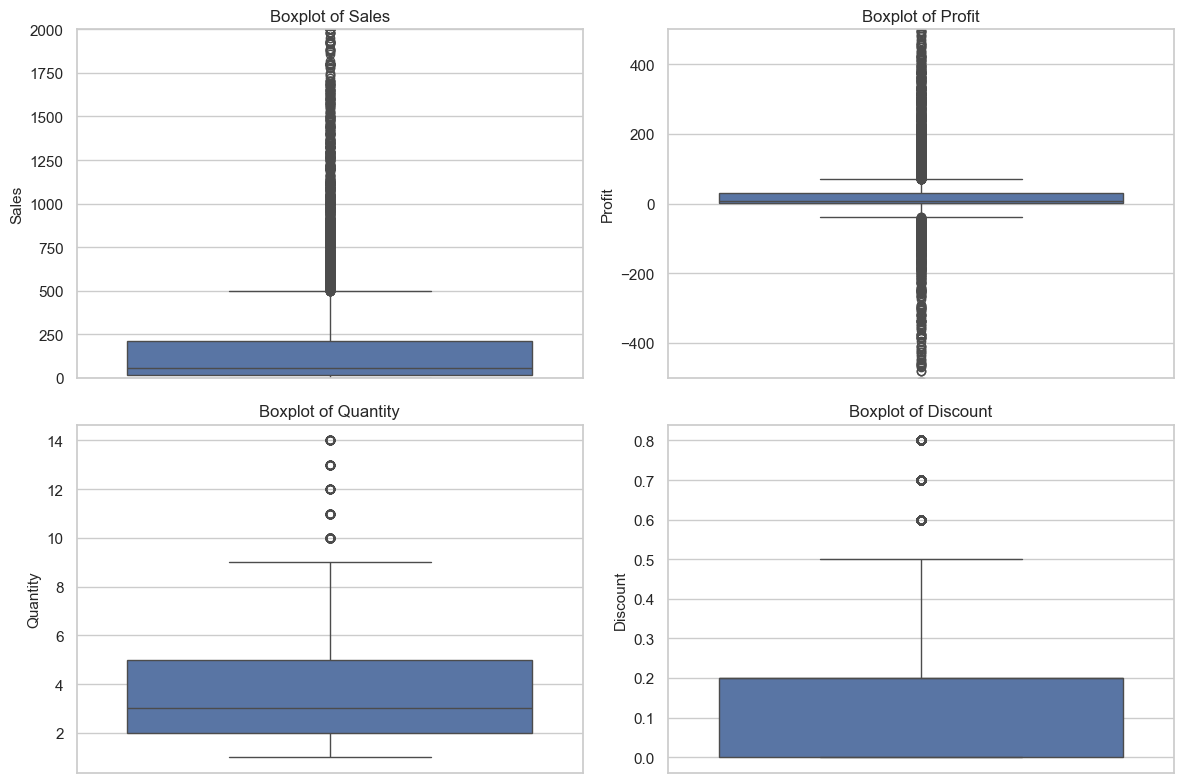

In [122]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

y_limits = {
    "Sales": (0, 2000),
    "Profit": (-500, 500),
    "Quantity": None,
    "Discount": None
}

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    
    if y_limits[col]:
        axes[i].set_ylim(y_limits[col])

plt.tight_layout()
plt.show()

Insights:
- Sales contains several high‑value outliers (large orders).
- Profit shows both high positive and large negative outliers.
- Discount has discrete levels (0%, 20%, 30%, etc.).
- Quantity has few extreme values, mostly small order sizes.

## 8. Geographical Analysis
I explore how sales activity varies across regions and product categories.

### 8.1 Region x Category

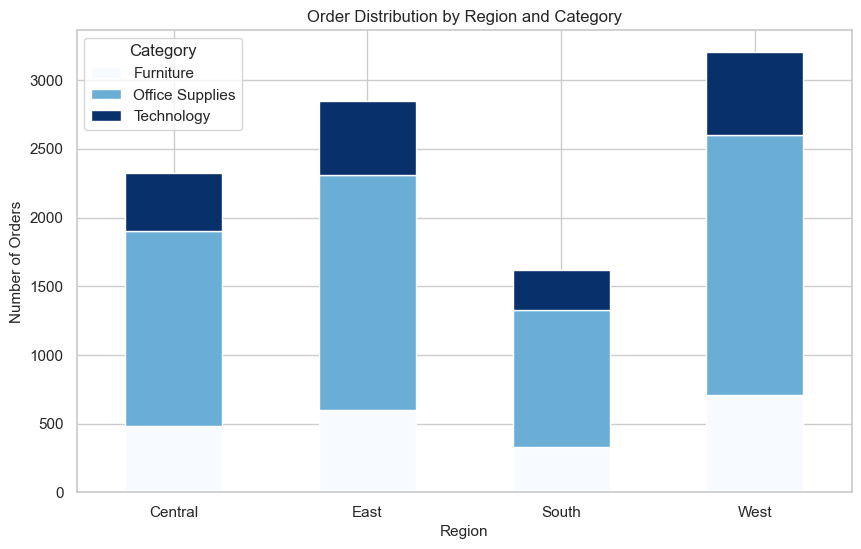

In [123]:
pd.crosstab(df["Region"], df["Category"]).plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="Blues"
)

plt.title("Order Distribution by Region and Category")
plt.ylabel("Number of Orders")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.show()

### 8.2 Profitability by Region

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\2868461047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


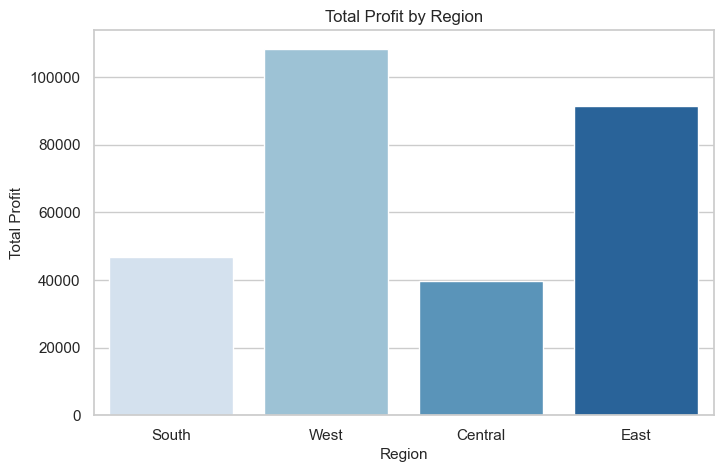

In [124]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Region",
    y="Profit",
    estimator="sum",
    errorbar=None,
    palette="Blues"
)
plt.title("Total Profit by Region")
plt.ylabel("Total Profit")
plt.show()

### 8.3 Profitability by Category

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\931109910.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


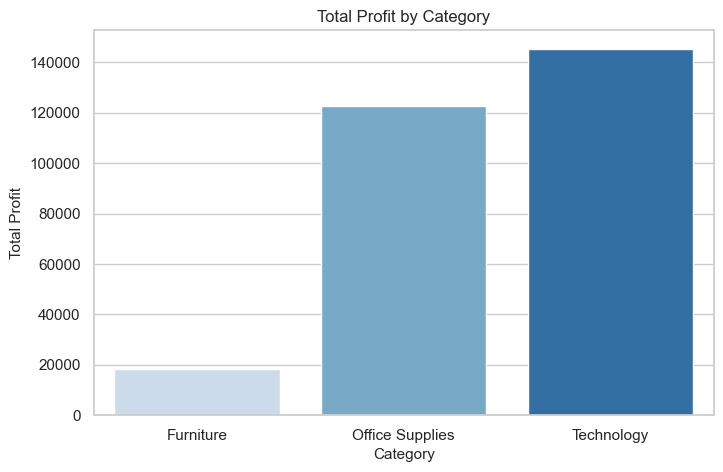

In [125]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Category",
    y="Profit",
    estimator="sum",
    errorbar=None,
    palette="Blues"
)
plt.title("Total Profit by Category")
plt.ylabel("Total Profit")
plt.show()


Insights:
- The West region has the highest order volume.
- Technology is the most profitable category across all regions.
- Furniture generates high sales but weak profit, likely due to discounts or shipping costs.



## 9. Time Series Analysis

### 9.1 Monthly Sales Trend
I begin by analyzing monthly sales to understand long‑term trends and overall business growth. Resampling the data at a monthly frequency smooths out daily fluctuations and highlights broader patterns.

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\1478849666.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample("M", on="Order Date")["Sales"]


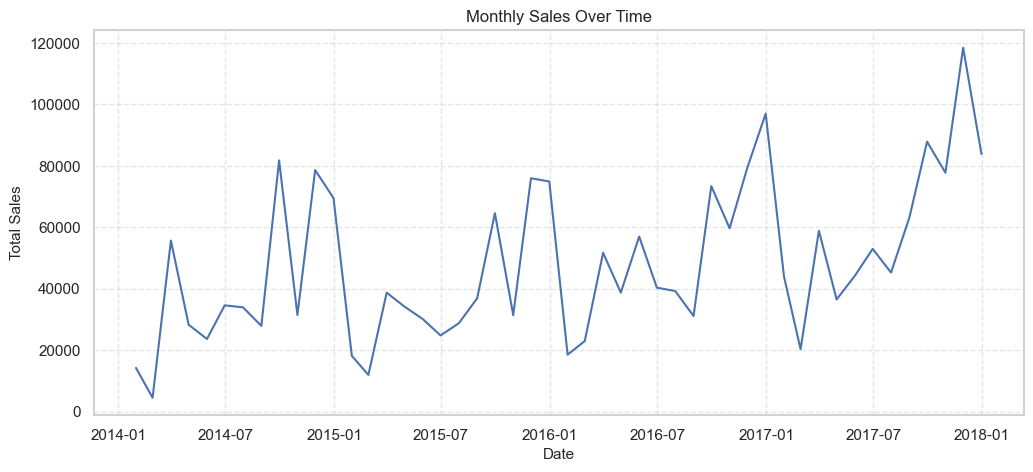

In [126]:
# 9.1 Monthly Sales

df = df.sort_values("Order Date")

monthly_sales = (
    df.resample("M", on="Order Date")["Sales"]
      .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, color="#4C72B0")
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Insights:
- Sales show a clear upward trend over the three‑year period.
- Several seasonal peaks appear, especially toward year‑end.

### 9.2 Monthly Profit Trend
Next, I analyze monthly profit to understand how profitability evolves over time and whether it follows the same pattern as sales.

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\3461993076.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample("M", on="Order Date")["Profit"]


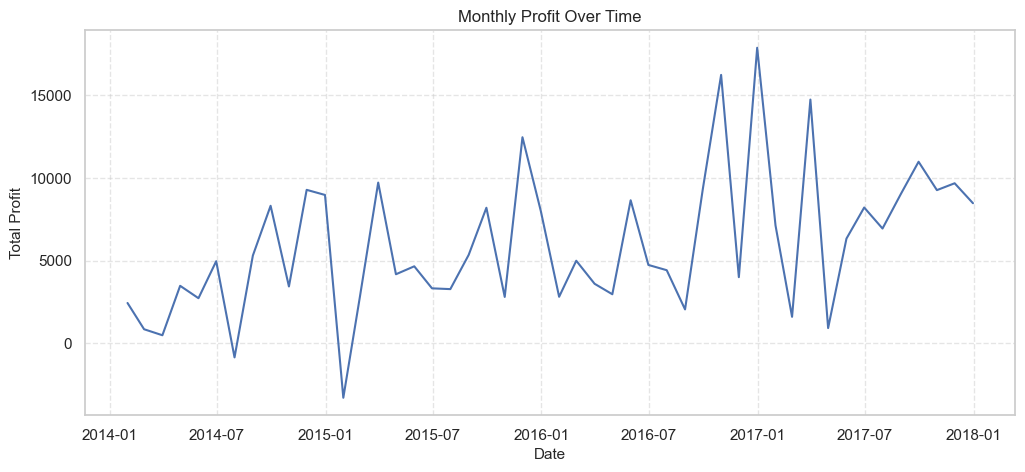

In [127]:
monthly_profit = (
    df.resample("M", on="Order Date")["Profit"]
      .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_profit.index, monthly_profit.values, color="#4C72B0")
plt.title("Monthly Profit Over Time")
plt.xlabel("Date")
plt.ylabel("Total Profit")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Insights:
- Profit fluctuates more than sales, indicating variability in discounting, shipping costs, or product mix.
- Some months show sharp drops.
- Profit does not always rise proportionally with sales.

### 9.3 Seasonality - Year-over-year comparison
To better understand seasonal patterns, I compare monthly sales across different years. This highlights recurring peaks (e.g., holiday season) and helps identify whether growth is consistent across months.

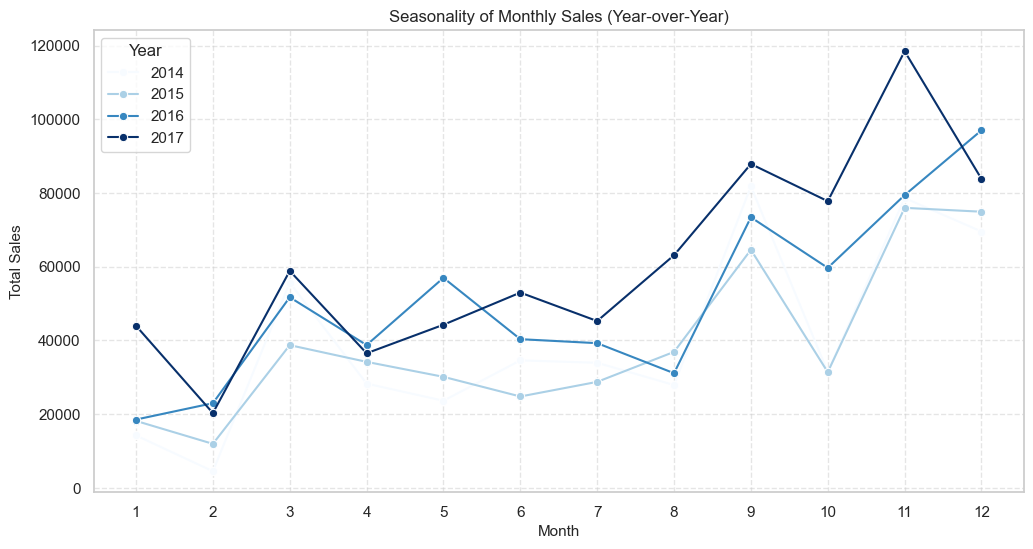

In [128]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

monthly = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o",
    palette="Blues"
)

plt.title("Seasonality of Monthly Sales (Year-over-Year)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



Insights:
- All years show similar seasonal patterns, with strong peaks in Q4.
- Year‑over‑year growth is visible, especially in the final year.
- Some months (e.g., February, July) consistently underperform, suggesting seasonal dips.

## 10. Product Profitability Analysis
I analyze total profit by sub‑category to identify which product groups drive profitability and which ones consistently underperform.

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\3429150358.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


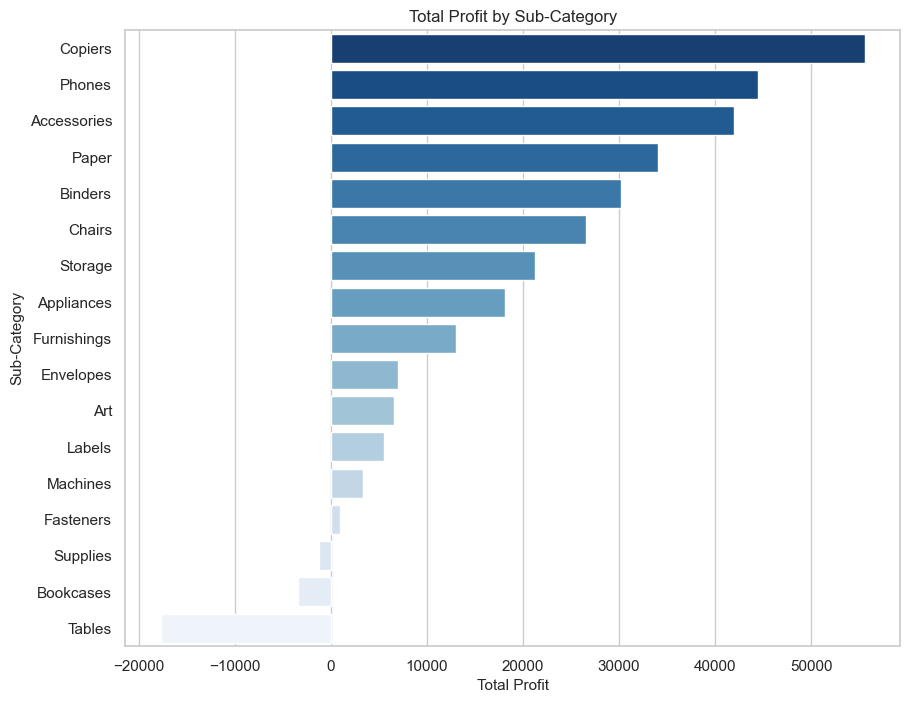

In [129]:
sub_cat = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .reset_index()
      .sort_values("Profit", ascending=False)
)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=sub_cat,
    x="Profit",
    y="Sub-Category",
    palette="Blues_r",
    errorbar=None
)
plt.title("Total Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.show()


Insights:
- A few sub‑categories (e.g., Copiers, Phones) generate the majority of profit.
- Several categories show negative profit, indicating structural issues such as discounting or high shipping costs.




## 11. Profit Margin Analysis
Profit margin is calculated as:
$$ Profit Margin = Total Profit / Total Sales $$
This metric helps compare profitability across categories regardless of sales volume.

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\3797300739.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


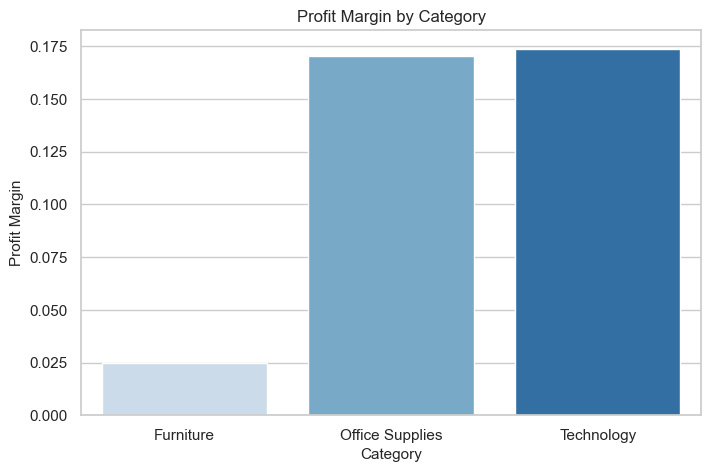

In [130]:
category_margin = (
    df.groupby("Category")
      .agg({"Profit": "sum", "Sales": "sum"})
      .reset_index()
)

category_margin["ProfitMargin"] = (
    category_margin["Profit"] / category_margin["Sales"]
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=category_margin,
    x="Category",
    y="ProfitMargin",
    palette="Blues",
    errorbar=None
)
plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")
plt.show()


Insights:
- Technology shows the strongest margins (high‑value items with good profitability).
- Furniture has high sales but weak margins, suggesting high shipping costs or discounting.
- Office Supplies has modest sales but surprisingly healthy margins.

## 12. Discount vs Profit Relationship
I examine how discount levels affect profitability.

A negative relationship would indicate that higher discounts reduce profit.

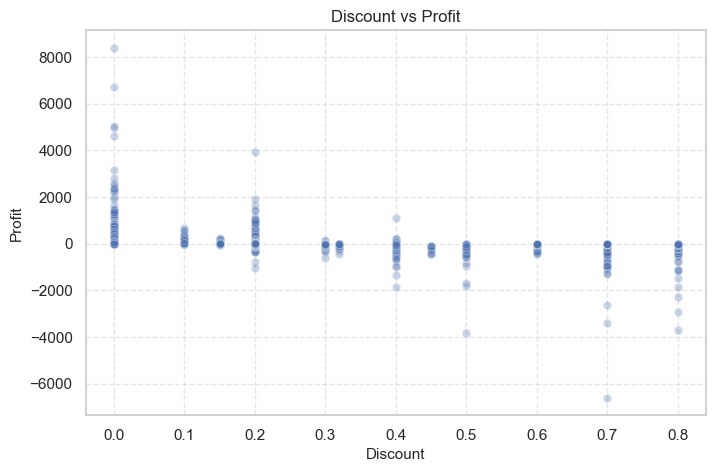

In [131]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.3,
    color="#4C72B0"
)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Insights:
- Higher discounts are strongly associated with negative profit.
- This confirms the earlier correlation matrix finding that discounting is a major driver of profit erosion.

## 13. Customer Segmenation Analysis

### 13.1 Sales by Customer Segment
I begin by analyzing sales distribution across customer segments to understand which groups contribute the most revenue.

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\1702682482.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


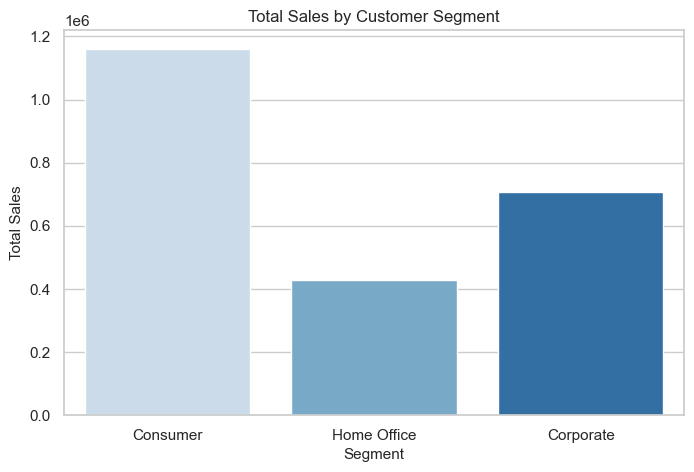

In [132]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Segment",
    y="Sales",
    estimator="sum",
    palette="Blues",
    errorbar=None
)
plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()


Insights:
- The Consumer segment generates the highest sales volume.
- Corporate and Home Office segments contribute less but still represent meaningful revenue streams.

### 13.2 Profit by Customer Segment

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\798053481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


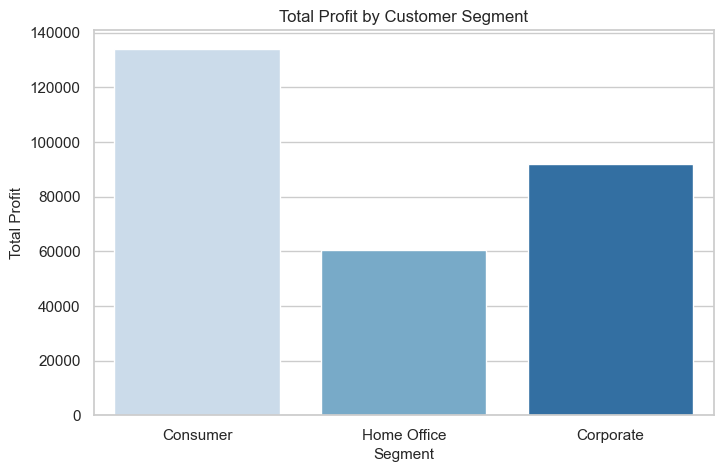

In [133]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Segment",
    y="Profit",
    estimator="sum",
    palette="Blues",
    errorbar=None
)
plt.title("Total Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.show()


## 14. Average Order Value
I calculate the Average Order Value (AOV) by summing sales per order and taking the mean.

### 14.1 OVerall AOV

In [134]:
avg_order_value = (
    df.groupby("Order ID")["Sales"]
      .sum()
      .reset_index()
)

aov = avg_order_value["Sales"].mean().round(2)
print(f"Average order value (AOV): {aov}")


Average order value (AOV): 458.61


### 14.2 AOV by Segment

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\2763510466.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


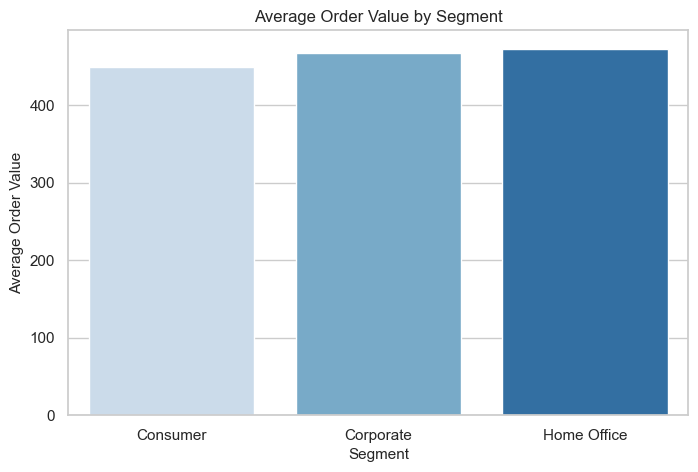

In [135]:
order_value = (
    df.groupby("Order ID")["Sales"]
      .sum()
      .reset_index()
      .rename(columns={"Sales": "OrderValue"})
)

segment_map = (
    df.groupby("Order ID")["Segment"]
      .first()
      .reset_index()
)

order_value_seg = order_value.merge(segment_map, on="Order ID")

avg_seg = (
    order_value_seg.groupby("Segment")["OrderValue"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=avg_seg,
    x="Segment",
    y="OrderValue",
    palette="Blues",
    errorbar=None
)
plt.title("Average Order Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Order Value")
plt.show()


Insights:
- Corporate customers tend to place larger orders on average.
- Consumer customers place more orders but with lower AOV.
- Home Office sits between the two.



## 15. Customer Analysis

### 15.1 Number of Orders per Customer

In [136]:
customer_map = (
    df.groupby("Order ID")["Customer ID"]
      .first()
      .reset_index()
)

orders_per_customer = (
    customer_map.groupby("Customer ID")["Order ID"]
      .count()
      .rename("Number_of_Orders")
)

avg_orders = orders_per_customer.mean().round(2)
print(f"Average number of orders per customer: {avg_orders}")


Average number of orders per customer: 6.32


Insights:
- Most customers place only a small number of orders.
- A small subset of customers may be responsible for a large share of revenue (Pareto effect).

### 15.2 Top and Bottom Customers

In [137]:
# Top Customers by Sales

top_customers = (
    df.groupby("Customer Name")
      .agg({"Sales": "sum", "Profit": "sum"})
      .sort_values("Sales", ascending=False)
)

top_customers.head(10)

,Sales,Profit
Customer Name,,
Sean Miller,25043.050,-1980.7393
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Tom Ashbrook,14595.620,4703.7883
Adrian Barton,14473.571,5444.8055
Ken Lonsdale,14175.229,806.8550
Sanjit Chand,14142.334,5757.4119
Hunter Lopez,12873.298,5622.4292
Sanjit Engle,12209.438,2650.6769


Highest Sale but lowest profit!

In [138]:
# Bottom Customers by Sales

bottom_customers = (
    df.groupby("Customer Name")
      .agg({"Sales": "sum", "Profit": "sum"})
      .sort_values("Sales", ascending=True)
)

bottom_customers.head(10)

,Sales,Profit
Customer Name,,
Thais Sissman,4.833,-3.3156
Lela Donovan,5.304,0.4641
Carl Jackson,16.520,1.6520
Mitch Gastineau,16.739,-1.2453
Roy Skaria,22.328,9.5838
Susan Gilcrest,47.946,-3.7073
Ricardo Emerson,48.360,6.0450
Larry Blacks,50.188,18.6507
Adrian Shami,58.820,21.8496


Insights:
- Some top‑spending customers generate low or even negative profit, likely due to heavy discounting.
- Bottom customers contribute little revenue and may not be worth targeted marketing efforts.

## 16. Key Insights from the Exploratory Data Analysis
The EDA reveals a business with strong growth, clear seasonal patterns, and uneven profitability across products, customers, and regions.
Discounting emerges as a major driver of profit erosion, while certain product categories and customer segments consistently outperform others.
### 1. Sales & Profit Patterns
- Sales and profit are heavily right‑skewed, driven by a small number of large transactions.
- Profit shows higher volatility than sales, with several months experiencing sharp drops.
- Clear year‑over‑year growth is visible, with strong seasonal peaks in Q4.

### 2. Impact of Discounting
- Higher discounts are strongly associated with lower profit, often turning orders unprofitable.
- Discount is one of the strongest negative correlates with profit.

### 3. Product Performance
- A few sub‑categories (e.g., Copiers, Phones) generate the majority of total profit.
- Several sub‑categories operate at a net loss, indicating structural issues such as high shipping costs or aggressive discounting.
- Technology has the highest margins, while Furniture shows high sales but weak profitability.

### 4. Customer Segments
- The Consumer segment contributes the most to both sales and profit.
- Corporate customers have the highest average order value (AOV).
- Home Office customers show weaker profitability relative to their sales volume.

### 5. Customer Behavior
- Most customers place only a few orders, but a small subset drives a large share of revenue.
- Some top‑spending customers generate low or negative profit, likely due to heavy discounting.

### 6. Regional Insights
- The West region has the highest order volume.
- Profitability varies significantly by region, likely due to differences in category mix and discounting.
- Some regions show strong sales but weaker margins.

### 7. Seasonality
- Sales show consistent seasonal peaks, especially in November and December.
- Certain months (e.g., February, July) consistently underperform across all years.
- Seasonality patterns are stable and useful for forecasting.

